In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
digits = load_digits()
x = digits.data
y = digits.target

print(f"Feature Matrix Shape: {x.shape}" )
print(f"Number of Classes : {len(set(y))}")
print(f"Feature Range : {x.min()} to {x.max()}")

Feature Matrix Shape: (1797, 64)
Number of Classes : 10
Feature Range : 0.0 to 16.0


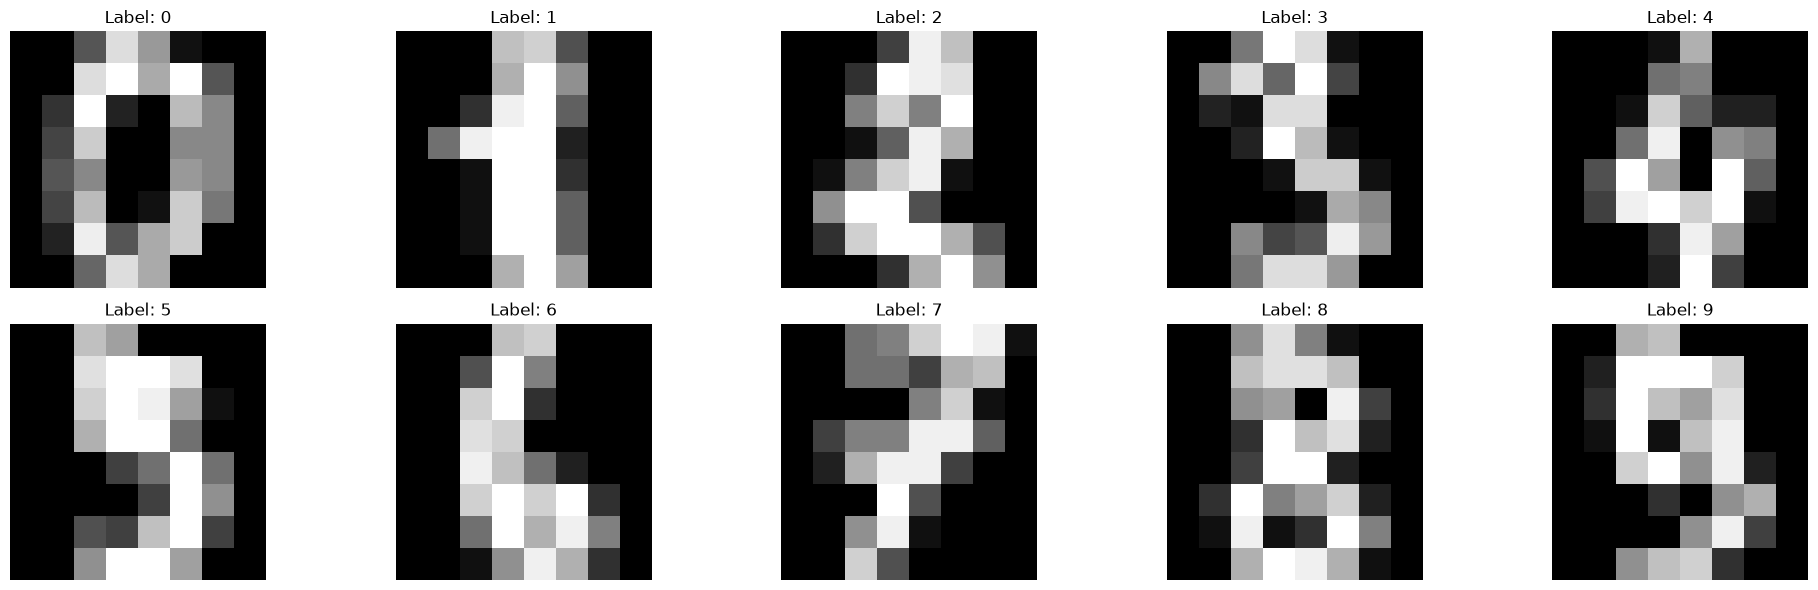

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
axes = axes.flatten()
for i,ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [29]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=42
)

print("Training Samples:", x_train.shape[0])
print("Testing Samples: ", x_test.shape[0])
print(x_test)

Training Samples: 1257
Testing Samples:  540
[[ 0.  0. 11. ... 16. 16. 12.]
 [ 0.  2. 13. ...  1.  0.  0.]
 [ 0.  0.  4. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... 16. 11.  0.]
 [ 0.  0.  0. ... 16.  3.  0.]
 [ 0.  0. 16. ... 16. 16.  9.]]


In [30]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Scaled Training Data Shape: ", x_train_scaled.shape)


Scaled Training Data Shape:  (1257, 64)


In [32]:
start_time = time.time()

baseline_model = LogisticRegression(max_iter=2000)
baseline_model.fit(x_train_scaled, y_train)
baseline_predictions = baseline_model.predict(x_test_scaled)

baseline_time = time.time() - start_time
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline (64 features):")
print(f"  Accuracy       : {baseline_accuracy:.4f}")
print(f"  Training time  : {baseline_time:.4f} seconds")


Baseline (64 features):
  Accuracy       : 0.9815
  Training time  : 0.0330 seconds


In [33]:
pca = PCA(n_components=0.95)  # keep enough components to explain 95% variance
X_train_pca = pca.fit_transform(x_train_scaled)
X_test_pca = pca.transform(x_test_scaled)

print("Number of PCA components selected:", pca.n_components_)
print("Total variance explained         : {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100))
print("Reduced feature shape (train)    :", X_train_pca.shape)

Number of PCA components selected: 39
Total variance explained         : 95.20%
Reduced feature shape (train)    : (1257, 39)


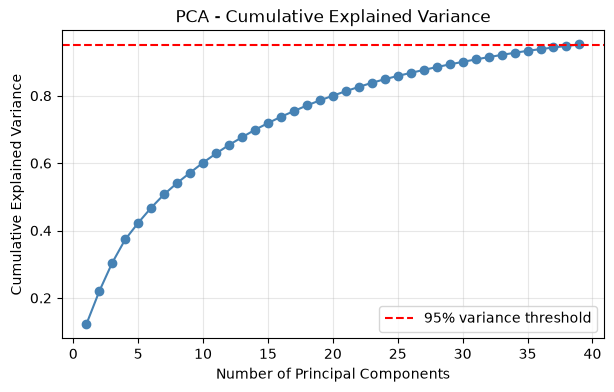

In [34]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", color="steelblue")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% variance threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [35]:
start_time = time.time()

pca_model = LogisticRegression(max_iter=2000)
pca_model.fit(X_train_pca, y_train)
pca_predictions = pca_model.predict(X_test_pca)

pca_time = time.time() - start_time
pca_accuracy = accuracy_score(y_test, pca_predictions)

print(f"PCA ({pca.n_components_} features):")
print(f"  Accuracy       : {pca_accuracy:.4f}")
print(f"  Training time  : {pca_time:.4f} seconds")

PCA (39 features):
  Accuracy       : 0.9630
  Training time  : 0.0276 seconds


In [47]:
lda = LinearDiscriminantAnalysis(n_components=9)
X_train_lda = lda.fit_transform(x_train_scaled, y_train)
X_test_lda = lda.transform(x_test_scaled)

print("Number of LDA components:", X_train_lda.shape[1])
print("Reduced feature shape (train):", X_train_lda.shape)

Number of LDA components: 9
Reduced feature shape (train): (1257, 9)


In [48]:
start_time = time.time()

lda_model = LogisticRegression(max_iter=2000)
lda_model.fit(X_train_lda, y_train)
lda_predictions = lda_model.predict(X_test_lda)

lda_time = time.time() - start_time
lda_accuracy = accuracy_score(y_test, lda_predictions)

print(f"LDA ({X_train_lda.shape[1]} features):")
print(f"  Accuracy       : {lda_accuracy:.4f}")
print(f"  Training time  : {lda_time:.4f} seconds")

LDA (9 features):
  Accuracy       : 0.9556
  Training time  : 0.0191 seconds


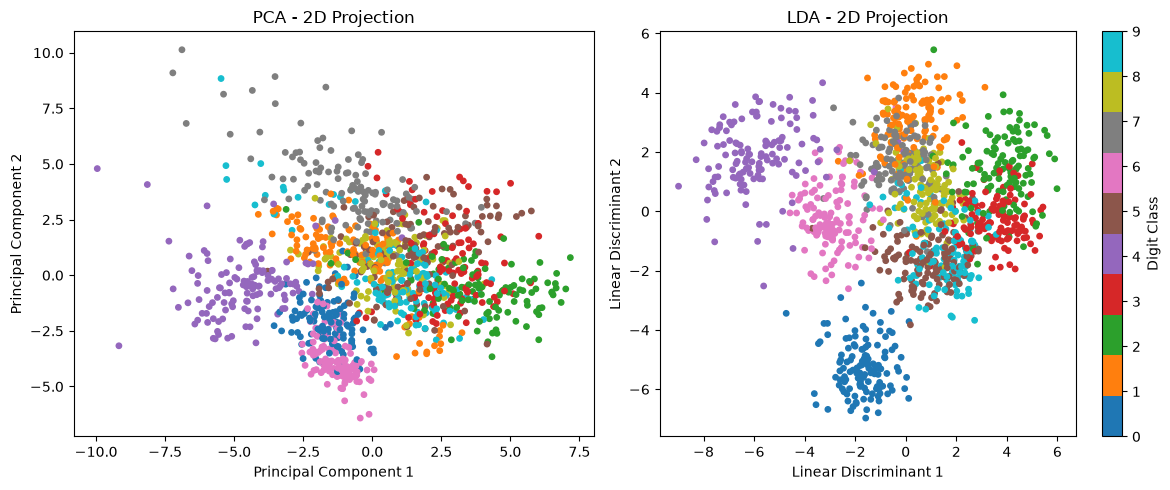

In [49]:
pca_2d = PCA(n_components=2).fit_transform(x_train_scaled)
lda_2d = LinearDiscriminantAnalysis(n_components=2).fit_transform(x_train_scaled, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter1 = axes[0].scatter(pca_2d[:, 0], pca_2d[:, 1], c=y_train, cmap="tab10", s=15)
axes[0].set_title("PCA - 2D Projection")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

scatter2 = axes[1].scatter(lda_2d[:, 0], lda_2d[:, 1], c=y_train, cmap="tab10", s=15)
axes[1].set_title("LDA - 2D Projection")
axes[1].set_xlabel("Linear Discriminant 1")
axes[1].set_ylabel("Linear Discriminant 2")

plt.colorbar(scatter2, ax=axes[1], label="Digit Class")
plt.tight_layout()
plt.show()

In [50]:
comparison_df = pd.DataFrame({
    "Method": ["No Reduction", "PCA", "LDA"],
    "Number of Features": [x_train_scaled.shape[1], X_train_pca.shape[1], X_train_lda.shape[1]],
    "Accuracy": [round(baseline_accuracy, 4), round(pca_accuracy, 4), round(lda_accuracy, 4)],
    "Training Time (s)": [round(baseline_time, 4), round(pca_time, 4), round(lda_time, 4)]
})

print(comparison_df)

         Method  Number of Features  Accuracy  Training Time (s)
0  No Reduction                  64    0.9815             0.0330
1           PCA                  39    0.9630             0.0276
2           LDA                   9    0.9556             0.0191


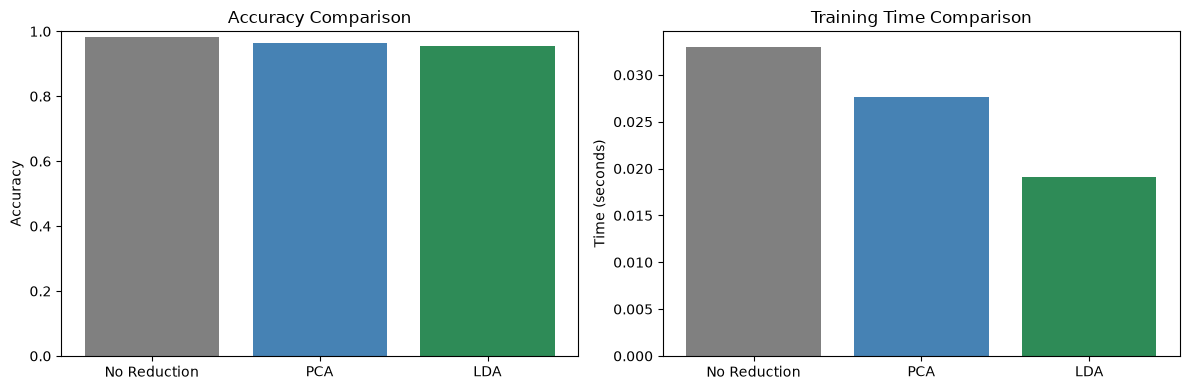

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(comparison_df["Method"], comparison_df["Accuracy"], color=["gray", "steelblue", "seagreen"])
axes[0].set_title("Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(comparison_df["Method"], comparison_df["Training Time (s)"], color=["gray", "steelblue", "seagreen"])
axes[1].set_title("Training Time Comparison")
axes[1].set_ylabel("Time (seconds)")

plt.tight_layout()
plt.show()

In [52]:
print("Experiment Completed Successfully")
print()
print(comparison_df)
print()
print("Observation:")
print(f"- PCA reduced features from {x_train_scaled.shape[1]} to {X_train_pca.shape[1]} (unsupervised, variance-based)")
print(f"- LDA reduced features from {x_train_scaled.shape[1]} to {X_train_lda.shape[1]} (supervised, class-separation-based)")
print("- Fewer features generally means faster training, with some trade-off in accuracy")

Experiment Completed Successfully

         Method  Number of Features  Accuracy  Training Time (s)
0  No Reduction                  64    0.9815             0.0330
1           PCA                  39    0.9630             0.0276
2           LDA                   9    0.9556             0.0191

Observation:
- PCA reduced features from 64 to 39 (unsupervised, variance-based)
- LDA reduced features from 64 to 9 (supervised, class-separation-based)
- Fewer features generally means faster training, with some trade-off in accuracy
